In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot

#from deep_translator import GoogleTranslator

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv') 
items     = pd.read_csv('olist_order_items_dataset.csv') 
reviews   = pd.read_csv('olist_order_reviews_dataset.csv') 
reviews_n = pd.read_csv('olist_order_reviews_dataset_no_duplicates.csv') 
reviews_transelated = pd.read_csv('eng_reviwe_remove_duplacated_lastone.csv')
orders    = pd.read_csv('olist_orders_dataset.csv') 
products  = pd.read_csv('olist_products_dataset.csv')
sellers   = pd.read_csv('olist_sellers_dataset.csv')
trans     = pd.read_csv('product_category_name_translation.csv', encoding='utf-8-sig')
geo       = pd.read_csv('olist_geolocation_dataset.csv') 
payments  = pd.read_csv('olist_order_payments_dataset.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_2344\1798155654.py:5: DtypeWarning: Columns (0: review_comment_title, 1: eng_review_comment_title) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_transelated = pd.read_csv('eng_reviwe_remove_duplacated_lastone.csv')


## Categories of customer reviews

In [49]:
reviews_n['review_score'].value_counts(normalize=True)

review_score
5    0.578295
4    0.193141
1    0.114643
3    0.082278
2    0.031643
Name: proportion, dtype: float64

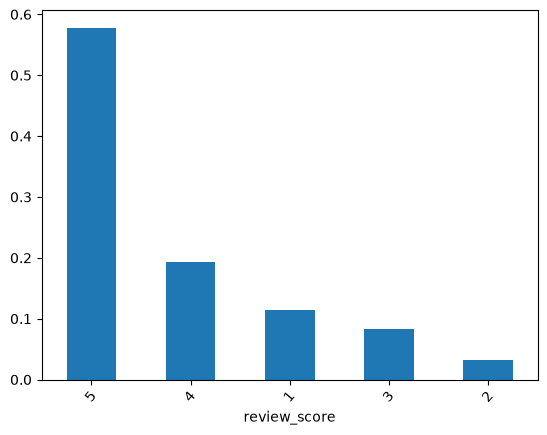

In [59]:
reviews_n['review_score'].value_counts(normalize=True).plot(kind="bar" , rot=50);

## What are the different categories of customer reviews? Explain each.
1- Highly unsatisfied : the product and shipment, price are below cutomer's expectation

2- Unsatisfied : the product and shipment, price did not meet cutomer's expectation

3- Neutral : Both efficiency and unefficiency were found in overall customer experience

4- Satisfied : the product and shipment, price met cutomer's expectation

5- Highly satisfied : the product and shipment, price exceeded cutomer's expectation

## -Are customers satisfied with Olist's products and services?

A high percentage of customers are satisfied Olist's products and services.


## Are we performing well or poorly in terms of customer satisfaction?

There are efficiency and unefficiency (areas of improvement) in acheiving customer satisfaction 

## Which KPIs best measure satisfaction; NPS, churn rate, repeat purchases, complaints, or reviews?

According to many proffisionals in Customer experience field : Net promoter satisfaction is the best KPI to measure but not applicable in our case

The churn rate measures the percentage of customers or employees leaving a company over a specific period.

Repeat purchases: a metric that measures repeated orders over a specific time

Complaints: negative comments given by customers 

Reviews: more comprehensive feedback that include score, reason, comment


In [30]:
reviews[reviews["review_comment_message"].str.contains("caro", case=False, na=False)].head(3)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
32665,b13013b811c2325934e8e049683bdcf2,51725d3e4bdfc97e28b40543310da8a3,1,NaN,Paguei mais caro e esperei mais tempo pra rece...,2016-10-27,2016-10-31 09:55:13
37580,0d53eac38f4797fcdadf26d7810dacb3,3d7d60b10ba4b43cf6f6d5df2e933f67,2,NaN,"muito caro, e mesmo comprando mais itens, vai ...",2016-11-01,2016-11-03 19:59:43
95385,46e746815b9560ce0b1df90666dca37e,62246c16a32a0866943f17d7b42db940,1,NaN,O frete é caro e ainda se quiser tem q buscar ...,2016-11-01,2016-11-03 23:19:32


In [31]:
reviews_n[reviews_n['review_comment_title'].str.contains("Recomendo", case=False, na=False)].head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
68209,a0e7ababec6161431a7cad78fcbb0514,541ed556b294e1dc5e80fb34a44917d3,4,recomendo,bom dentro das expectativas,2018-04-25,2018-04-26 13:58:56
68263,161a1f245c7f56d6fe1503c285980b71,753e0ba8400bf53314098772093ca9bb,2,não recomendo,não atendem solicitações,2018-03-22,2018-04-26 18:48:37
68269,330fe0ce99ba24f9e8c1fe4493ecf9b9,ffc2926aeab97ab6dc7585276c9b9371,5,Recomendo,Gosto de acompanhar o pedido e essa empresa no...,2018-04-26,2018-04-26 19:15:43


In [32]:
reviews_n[
    reviews_n['review_comment_title'].str.contains("Recomendo", case=False, na=False)
    & reviews_n['review_score'].isin([4, 5])
].head(3)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
68209,a0e7ababec6161431a7cad78fcbb0514,541ed556b294e1dc5e80fb34a44917d3,4,recomendo,bom dentro das expectativas,2018-04-25,2018-04-26 13:58:56
68269,330fe0ce99ba24f9e8c1fe4493ecf9b9,ffc2926aeab97ab6dc7585276c9b9371,5,Recomendo,Gosto de acompanhar o pedido e essa empresa no...,2018-04-26,2018-04-26 19:15:43
68291,98fc0420babf19baa0c1597b41e91364,c85fe66e2c1cb66a9461604acc956de9,5,Super recomendo,NaN,2018-04-24,2018-04-26 20:36:18


In [33]:
reviews_n['review_comment_title'].value_counts(normalize=True)

review_comment_title
Recomendo                0.036635
recomendo                0.029864
Bom                      0.025263
super recomendo          0.023266
Excelente                0.021530
                           ...   
Pedido 02-671663252      0.000087
Empres não confiável     0.000087
super recomendo...       0.000087
òtimo                    0.000087
Cancelaram a compra      0.000087
Name: proportion, Length: 4527, dtype: float64

## Where are highest and least reviews?

A- Highest reviews are positive (scoring 4 & 5) reaching 75,917 77%

B- Least reviews are negative scoring 1 reaching  3114 3%

In [61]:

state_to_region = {
    
    'AC': 'North',
    'AP': 'North',
    'AM': 'North',
    'PA': 'North',
    'RO': 'North',
    'RR': 'North',
    'TO': 'North',

    
    'AL': 'Northeast',
    'BA': 'Northeast',
    'CE': 'Northeast',
    'MA': 'Northeast',
    'PB': 'Northeast',
    'PE': 'Northeast',
    'PI': 'Northeast',
    'RN': 'Northeast',
    'SE': 'Northeast',

    
    'DF': 'Central-West',
    'GO': 'Central-West',
    'MT': 'Central-West',
    'MS': 'Central-West',

    
    'ES': 'Southeast',
    'MG': 'Southeast',
    'RJ': 'Southeast',
    'SP': 'Southeast',

    
    'PR': 'South',
    'RS': 'South',
    'SC': 'South'
}


In [67]:

reviews_region = (
    reviews[['order_id', 'review_id']]
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
)


reviews_region['region'] = reviews_region['customer_state'].map(state_to_region)


region_reviews = (
    reviews_region
    .groupby('region')['review_id']
    .count()
    .sort_values(ascending=False)
)

print(region_reviews)

highest_region = region_reviews.idxmax()
highest_reviews = region_reviews.max()

least_region = region_reviews.idxmin()
least_reviews = region_reviews.min()

print(f"Highest reviews: {highest_region} ({highest_reviews:,})")
print(f"Least reviews: {least_region} ({least_reviews:,})")



region
Southeast       67462
South           14026
Northeast        9277
Central-West     5725
North            1820
Name: review_id, dtype: int64
Highest reviews: Southeast (67,462)
Least reviews: North (1,820)


In [76]:
reviews_region.to_csv("aaaaaaaaaaa.csv")

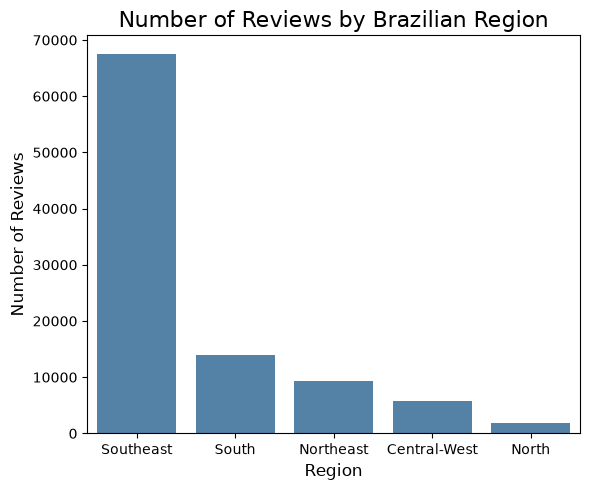

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.barplot(
    x=region_reviews.index,
    y=region_reviews.values,
    color='steelblue'
)

plt.title('Number of Reviews by Brazilian Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


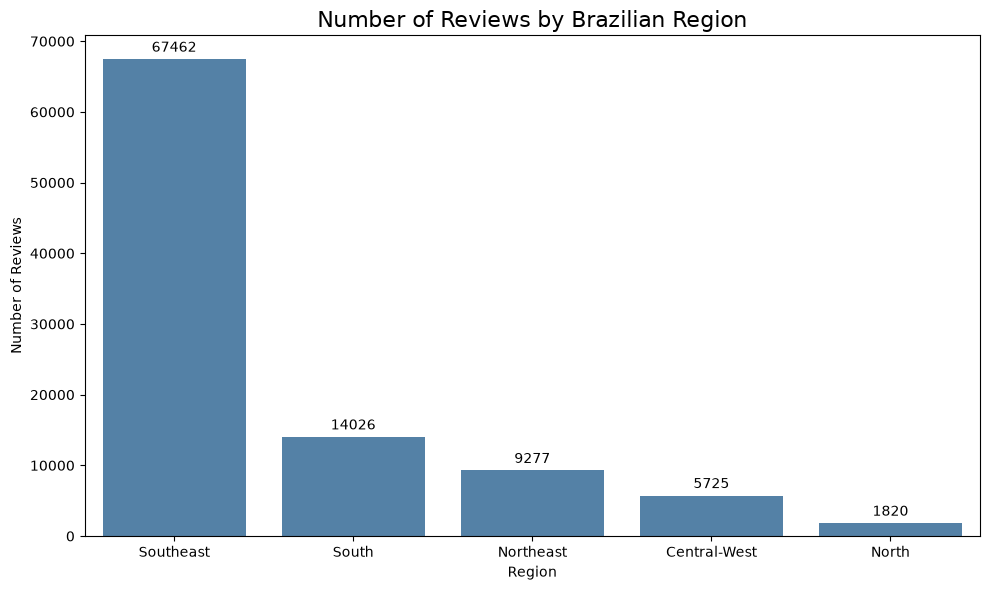

In [69]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=region_reviews.index,
    y=region_reviews.values,
    color='steelblue'
)

plt.title('Number of Reviews by Brazilian Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Number of Reviews')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()


In [43]:
reviews_n['review_score'].value_counts(normalize=True) *100

review_score
5    57.829489
4    19.314094
1    11.464282
3     8.227822
2     3.164313
Name: proportion, dtype: float64

## 5 regions of Brazil

A- Central west

pop:16,504,303 and industry 6% of the country's industrial GDP

B-Southeast

White	55.0%
Mixed	38.7%
Black	5.6%
Asian	0.7%
Indigenous	0.1%

Vehicles: 36,030,943 - Telephones: 23,878,000

C-South

pop: 29.9 m
White	82.6%
Mixed	11.7%
Black	5.0%
East Asian	0.4%
Indigenous	0.3%

D-Northeast

pop: 18.29m
Multiracial	59.6%
White	26.7%
Black	13.0%
Amerindian	0.6%
Asian	0.1%

Nordeste has the largest percentage of Roman Catholics of any region of the country

E-North

pop: 17.3 million

Multiracial	67.2%
White	20.7%
Black	8.8%
Amerindian	3.1%
Asian	0.2%

Vehicles: 1,746,501 - Telephones: 1,805,000 - Cities: 449

Key economic influences:

Industrialization: Major cities are industrial hubs, driving economic growth and attracting workers.
Tourism: Coastal cities like Rio de Janeiro and Salvador benefit from tourism, boosting local economies.
Government Policies: Urban development programs aim to reduce inequality, but rural areas still face challenges.


## how can we improve customer experience and satisfaction

According to comments

1- deliver the item within the deadline

2- deliver all ordered items

3- Better communication with customers regarding latest updates

4- Improve quality and good packaging of product

In [10]:
reviews_transelated["eng_review_comment_message"]

0        I did not receive the product nor a response f...
1        The product did not arrive, and the delivery d...
2                                                      NaN
3               The order was delivered ahead of schedule.
4               Only part of the order has arrived so far.
                               ...                        
98405                                                  NaN
98406                                                  NaN
98407    I loved the little table, what a shame I got t...
98408                                                  NaN
98409                                                  NaN
Name: eng_review_comment_message, Length: 98410, dtype: str